# EEG Analysis: C9orf72-KO vs WT — Longitudinal Study

**Study design:**

| Age | Recording type | Analysis |
|-----|---------------|----------|
| 3 months | 24h baseline EEG | Power spectral density |
| 4 months | 4h post kainic acid injection | Seizure-associated discharge detection |
| 6 months | 24h follow-up EEG | Power spectral density |
| 12 months | 24h follow-up EEG | Power spectral density |

**Biological question:** Do C9orf72-KO mice show progressive increases in network hyperexcitability compared to WT controls across disease progression?

---

## 0. Setup

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

sys.path.insert(0, os.path.join("..", "src"))

from preprocessing import load_abf, remove_artifacts, estimate_baseline, load_group_from_manifest
from detection import detect_discharges, compute_psd, compute_band_power, process_group
from classify import build_feature_matrix, train_classifier, evaluate_classifier, plot_feature_importance, plot_roc_and_pr

plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

FIGURES_DIR = os.path.join("..", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)
print("Environment ready.")

Environment ready.


## 1. Data paths

In [3]:
BASE = r"C:\Users\belay\OneDrive\Desktop\EEG analysis"

PATHS = {
    "3m": {
        "WT": os.path.join(BASE, "Baseline EEG", "WT"),
        "KO": os.path.join(BASE, "Baseline EEG", "KO"),
        "manifest_wt": "abf_files_start_times_wt.xlsx",
        "manifest_ko": "abf_files_start_times_ko.xlsx",
    },
    "4m_KA": {
        "WT": os.path.join(BASE, "KA EEG", "WT"),
        "KO": os.path.join(BASE, "KA EEG", "KO"),
    },
    "6m": {
        "WT": os.path.join(BASE, "Six Months EEG", "WT"),
        "KO": os.path.join(BASE, "Six Months EEG", "KO"),
        "manifest_wt": "abf_files_start_times_wt_6m.xlsx",
        "manifest_ko": "abf_files_start_times_ko_6m.xlsx",
    },
    "12m": {
        "WT": os.path.join(BASE, "One Year EEG", "WT"),
        "KO": os.path.join(BASE, "One Year EEG", "KO"),
        "manifest_wt": "abf_files_start_times_wt_1y.xlsx",
        "manifest_ko": "abf_files_start_times_ko_1y.xlsx",
    },
}

print("Checking paths:")
for timepoint, dirs in PATHS.items():
    wt_ok = os.path.exists(dirs["WT"])
    ko_ok = os.path.exists(dirs["KO"])
    print(f"  {timepoint}: WT={'OK' if wt_ok else 'NOT FOUND'} | KO={'OK' if ko_ok else 'NOT FOUND'}")

Checking paths:
  3m: WT=OK | KO=OK
  4m_KA: WT=OK | KO=OK
  6m: WT=OK | KO=OK
  12m: WT=OK | KO=OK


## 2. SAD detection — 4-month kainic acid recordings

Full recordings scanned automatically. No start times needed — the algorithm detects epileptiform discharges across the entire 4h trace using adaptive thresholding.

In [4]:
def process_full_recordings(data_dir):
    rows = []
    abf_files = [f for f in os.listdir(data_dir) if f.endswith(".abf")]
    print(f"  Found {len(abf_files)} ABF files in {os.path.basename(data_dir)}")
    for fname in abf_files:
        fpath = os.path.join(data_dir, fname)
        try:
            time, voltage, fs = load_abf(fpath)
            time, voltage = remove_artifacts(time, voltage)
            baseline = estimate_baseline(voltage, fs)
            lower_threshold = 2.0 * baseline
            events = detect_discharges(time, voltage, fs, lower_threshold=lower_threshold)
            duration_min = len(time) / fs / 60
            rows.append({
                "file": fname,
                "n_events": len(events),
                "rate_per_min": len(events) / duration_min if duration_min > 0 else 0,
                "mean_voltage_mV": events["voltage_mV"].mean() if len(events) > 0 else 0,
                "std_voltage_mV": events["voltage_mV"].std() if len(events) > 0 else 0,
                "mean_prominence": events["prominence"].mean() if len(events) > 0 else 0,
                "duration_min": duration_min,
                "baseline_mV": baseline,
            })
            print(f"    {fname}: {len(events)} events | {len(events)/duration_min:.2f} events/min")
        except Exception as e:
            print(f"    ERROR — {fname}: {e}")
    return pd.DataFrame(rows)

print("Processing WT...")
sad_wt = process_full_recordings(PATHS["4m_KA"]["WT"])
print("\nProcessing KO...")
sad_ko = process_full_recordings(PATHS["4m_KA"]["KO"])

Processing WT...
  Found 16 ABF files in WT
    21507001.abf: 3808 events | 31.73 events/min
    21507002.abf: 3364 events | 28.03 events/min
    21513008.abf: 2988 events | 24.90 events/min
    21513009.abf: 0 events | 0.00 events/min
    21517010.abf: 6 events | 0.05 events/min
    21517011.abf: 266 events | 2.22 events/min
    21518009.abf: 0 events | 0.00 events/min
    21518010.abf: 263 events | 2.19 events/min
    21519009.abf: 643 events | 5.36 events/min
    21519010.abf: 150 events | 1.25 events/min
    21520008.abf: 3161 events | 26.34 events/min
    21520009.abf: 482 events | 4.02 events/min
    21521001.abf: 2965 events | 24.71 events/min
    21521002.abf: 3683 events | 30.69 events/min
    21521009.abf: 0 events | 0.00 events/min
    21521010.abf: 0 events | 0.00 events/min

Processing KO...
  Found 18 ABF files in KO
    21508005.abf: 0 events | 0.00 events/min
    21508006.abf: 0 events | 0.00 events/min
    21510001.abf: 1524 events | 12.70 events/min
    21510002.abf: 

### 2a. Example EEG trace with detected discharges

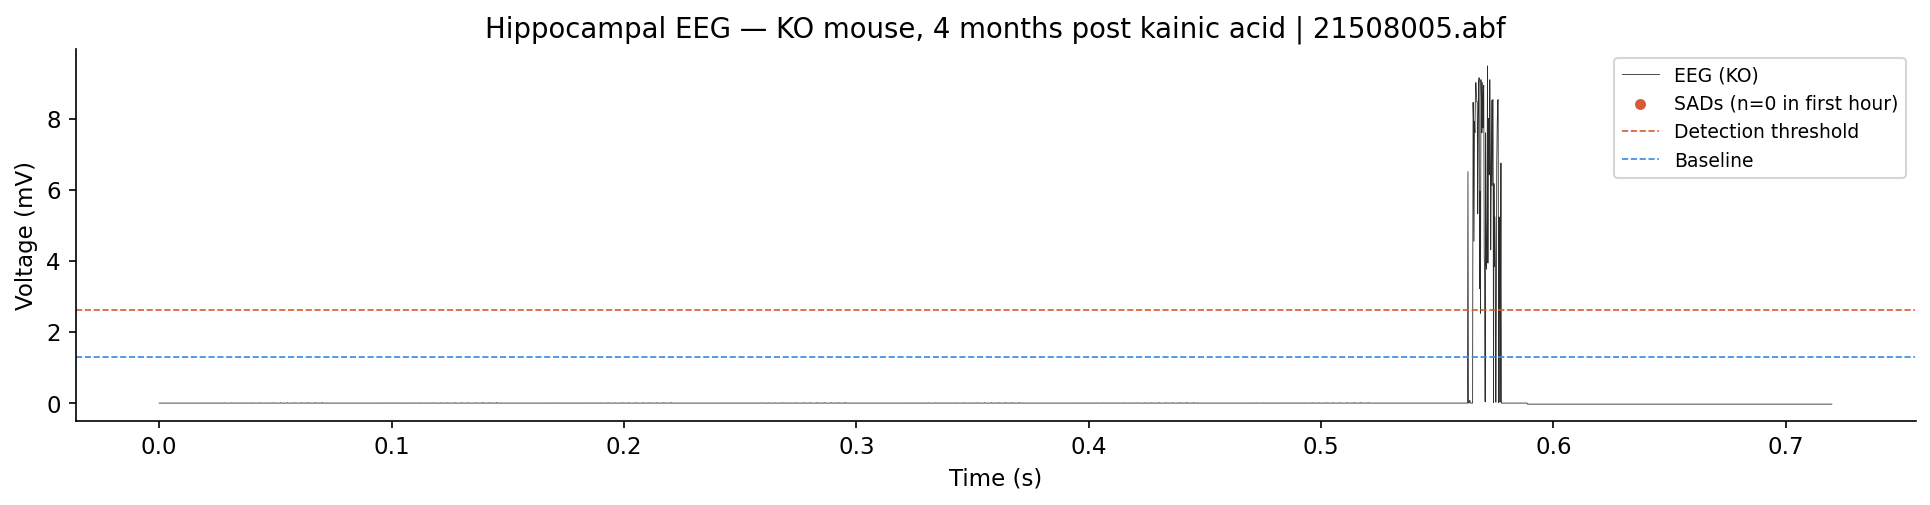

In [5]:
ko_files = [f for f in os.listdir(PATHS["4m_KA"]["KO"]) if f.endswith(".abf")]
time, voltage, fs = load_abf(os.path.join(PATHS["4m_KA"]["KO"], ko_files[0]))
time, voltage = remove_artifacts(time, voltage)
baseline = estimate_baseline(voltage, fs)
events = detect_discharges(time, voltage, fs, lower_threshold=2.0 * baseline)

t_plot = time[:3600]
v_plot = voltage[:3600]
ev_plot = events[events["time_s"] <= t_plot[-1]]

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(t_plot, v_plot, color="#2C2C2A", lw=0.4, label="EEG (KO)")
ax.scatter(ev_plot["time_s"], ev_plot["voltage_mV"], color="#D85A30", s=18, zorder=5,
           label=f"SADs (n={len(ev_plot)} in first hour)")
ax.axhline(2.0 * baseline, color="#D85A30", lw=0.8, ls="--", label="Detection threshold")
ax.axhline(baseline, color="#378ADD", lw=0.8, ls="--", label="Baseline")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Voltage (mV)")
ax.set_title(f"Hippocampal EEG — KO mouse, 4 months post kainic acid | {ko_files[0]}")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "eeg_trace_ko_4m.png"), dpi=150, bbox_inches="tight")
plt.show()

### 2b. Discharge rate: WT vs KO

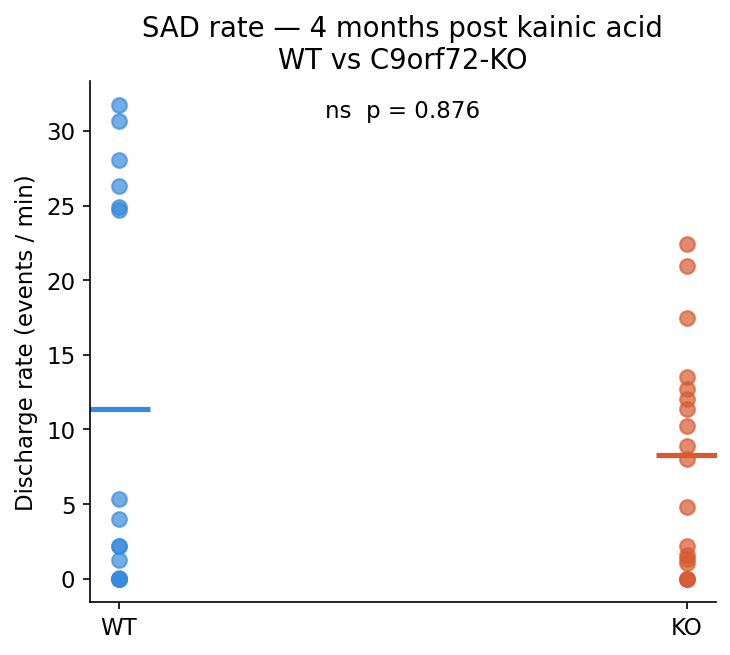

WT  mean ± SD: 11.343 ± 13.308 events/min
KO  mean ± SD: 8.257 ± 7.366 events/min
Mann-Whitney U: stat=149.0, p=0.8761 (ns)


In [6]:
stat, pval = mannwhitneyu(sad_wt["rate_per_min"], sad_ko["rate_per_min"], alternative="two-sided")
sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"

fig, ax = plt.subplots(figsize=(5, 4.5))
colors = {"WT": "#378ADD", "KO": "#D85A30"}
for label, df_g in [("WT", sad_wt), ("KO", sad_ko)]:
    ax.scatter([label] * len(df_g), df_g["rate_per_min"],
               color=colors[label], alpha=0.7, s=50, zorder=3)
    ax.plot([label], [df_g["rate_per_min"].mean()],
            marker="_", markersize=30, markeredgewidth=2.5, color=colors[label])
ax.annotate(f"{sig}  p = {pval:.3f}", xy=(0.5, 0.93), xycoords="axes fraction", ha="center", fontsize=11)
ax.set_ylabel("Discharge rate (events / min)")
ax.set_title("SAD rate — 4 months post kainic acid\nWT vs C9orf72-KO")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "sad_rate_wt_vs_ko.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"WT  mean ± SD: {sad_wt['rate_per_min'].mean():.3f} ± {sad_wt['rate_per_min'].std():.3f} events/min")
print(f"KO  mean ± SD: {sad_ko['rate_per_min'].mean():.3f} ± {sad_ko['rate_per_min'].std():.3f} events/min")
print(f"Mann-Whitney U: stat={stat:.1f}, p={pval:.4f} ({sig})")

## 3. Longitudinal PSD — 3, 6, and 12 months

Normalized PSD from baseline epoch recordings at three timepoints.
Tracks how spectral signatures evolve with disease progression.

In [11]:
import os

def build_file_index(data_dir):
    """Build a lookup dictionary: filename -> full path, searching all subfolders."""
    index = {}
    for root, dirs, files in os.walk(data_dir):
        for fname in files:
            if fname.endswith(".abf"):
                index[fname] = os.path.join(root, fname)
    return index

def compute_group_psd_lowmem(data_dir, manifest_filename):
    manifest = pd.read_excel(os.path.join(data_dir, manifest_filename))
    file_index = build_file_index(data_dir)
    print(f"    Found {len(file_index)} ABF files across all subfolders")
    
    psd_list = []
    freq_out = None

    for _, row in manifest.iterrows():
        fname = row["File"]
        if fname not in file_index:
            print(f"  SKIP {fname}: not found in any subfolder")
            continue
        file_path = file_index[fname]
        
        start_times = [
            float(t.strip())
            for t in str(row["Start_Times"]).split(",")
            if t.strip()
        ]
        for start_min in start_times:
            try:
                import pyabf, gc
                abf = pyabf.ABF(file_path)
                fs = abf.dataRate
                start_idx = int(start_min * 60 * fs)
                end_idx = int((start_min + 0.5) * 60 * fs)
                abf.setSweep(0)
                epoch = abf.sweepY[start_idx:end_idx].copy()
                del abf
                gc.collect()

                freq, psd = compute_psd(epoch, fs)
                del epoch
                gc.collect()

                psd_list.append(psd)
                if freq_out is None:
                    freq_out = freq

            except MemoryError:
                print(f"  SKIP {fname} @ {start_min}min: not enough RAM")
            except Exception as e:
                print(f"  ERROR {fname} @ {start_min}min: {e}")

    if not psd_list:
        return None, None, None, 0

    max_len = max(len(p) for p in psd_list)
    psd_array = np.array([np.pad(p, (0, max_len - len(p))) for p in psd_list])
    return freq_out, psd_array.mean(axis=0), psd_array.std(axis=0), len(psd_list)


psd_results = {}
for tp in ["3m", "6m", "12m"]:
    print(f"\nProcessing {tp}...")
    for group in ["WT", "KO"]:
        freq, mean_psd, std_psd, n = compute_group_psd_lowmem(
            PATHS[tp][group], PATHS[tp][f"manifest_{group.lower()}"]
        )
        psd_results[(tp, group)] = {
            "freq": freq, "mean": mean_psd, "std": std_psd, "n": n
        }
        print(f"  {group}: {n} epochs loaded")


Processing 3m...
    Found 100 ABF files across all subfolders
  SKIP 21427009.abf: not found in any subfolder
  SKIP 21427010.abf: not found in any subfolder
  SKIP 21427011.abf: not found in any subfolder
  SKIP 21427012.abf: not found in any subfolder
  SKIP 21428000.abf: not found in any subfolder
  SKIP 21428001.abf: not found in any subfolder
  SKIP 21428002.abf: not found in any subfolder
  SKIP 21428003.abf: not found in any subfolder
  SKIP 21428004.abf: not found in any subfolder
  SKIP 21428005.abf: not found in any subfolder
  SKIP 21428006.abf: not found in any subfolder
  WT: 740 epochs loaded
    Found 99 ABF files across all subfolders
  SKIP 21415001.abf: not found in any subfolder
  SKIP 21415006.abf: not found in any subfolder
  KO: 1067 epochs loaded

Processing 6m...
    Found 94 ABF files across all subfolders
  WT: 1093 epochs loaded
    Found 89 ABF files across all subfolders
  KO: 1405 epochs loaded

Processing 12m...
    Found 190 ABF files across all subfol

In [13]:
# Find the shortest frequency array across all results
min_len = min(
    len(r["freq"]) 
    for r in psd_results.values() 
    if r["freq"] is not None
)

# Trim all arrays to the same length
for key in psd_results:
    r = psd_results[key]
    if r["freq"] is not None:
        r["freq"] = r["freq"][:min_len]
        r["mean"] = r["mean"][:min_len]
        r["std"] = r["std"][:min_len]

print(f"All PSDs aligned to {min_len} frequency points")

# Check what frequency range we have
sample = next(r for r in psd_results.values() if r["freq"] is not None)
print(f"Frequency range: {sample['freq'][0]:.2f} to {sample['freq'][-1]:.2f} Hz")

All PSDs aligned to 11 frequency points
Frequency range: 0.00 to 24.41 Hz


In [17]:
from scipy.interpolate import interp1d

# Common frequency axis 0.5 to 50 Hz
common_freq = np.linspace(0.5, 50, 200)

# Interpolate all PSDs onto common axis
for key in psd_results:
    r = psd_results[key]
    if r["freq"] is None:
        continue
    
    # Only interpolate within the valid range of each recording
    valid_max = r["freq"][-1]
    valid_min = r["freq"][r["freq"] > 0][0] if any(r["freq"] > 0) else 0.5
    
    # Create interpolator
    f_mean = interp1d(r["freq"], r["mean"], bounds_error=False, fill_value=0)
    f_std = interp1d(r["freq"], r["std"], bounds_error=False, fill_value=0)
    
    r["freq"] = common_freq
    r["mean"] = f_mean(common_freq)
    r["std"] = f_std(common_freq)

print("All PSDs interpolated to common frequency axis: 0.5 to 50 Hz")

# Verify
for tp in timepoints:
    for group in ["WT", "KO"]:
        r = psd_results[(tp, group)]
        bp = compute_band_power(r["freq"], r["mean"])
        print(f"{tp} {group}: gamma={bp['gamma']:.4f} | beta={bp['beta']:.4f} | theta={bp['theta']:.4f}")

All PSDs interpolated to common frequency axis: 0.5 to 50 Hz
3m WT: gamma=0.0000 | beta=0.1291 | theta=0.2797
3m KO: gamma=0.0000 | beta=0.1309 | theta=0.2968
6m WT: gamma=0.0000 | beta=0.1047 | theta=0.3032
6m KO: gamma=0.0000 | beta=0.1129 | theta=0.3022
12m WT: gamma=0.0565 | beta=0.2034 | theta=0.2794
12m KO: gamma=0.1439 | beta=0.5585 | theta=0.3727


### 3a. PSD across all timepoints

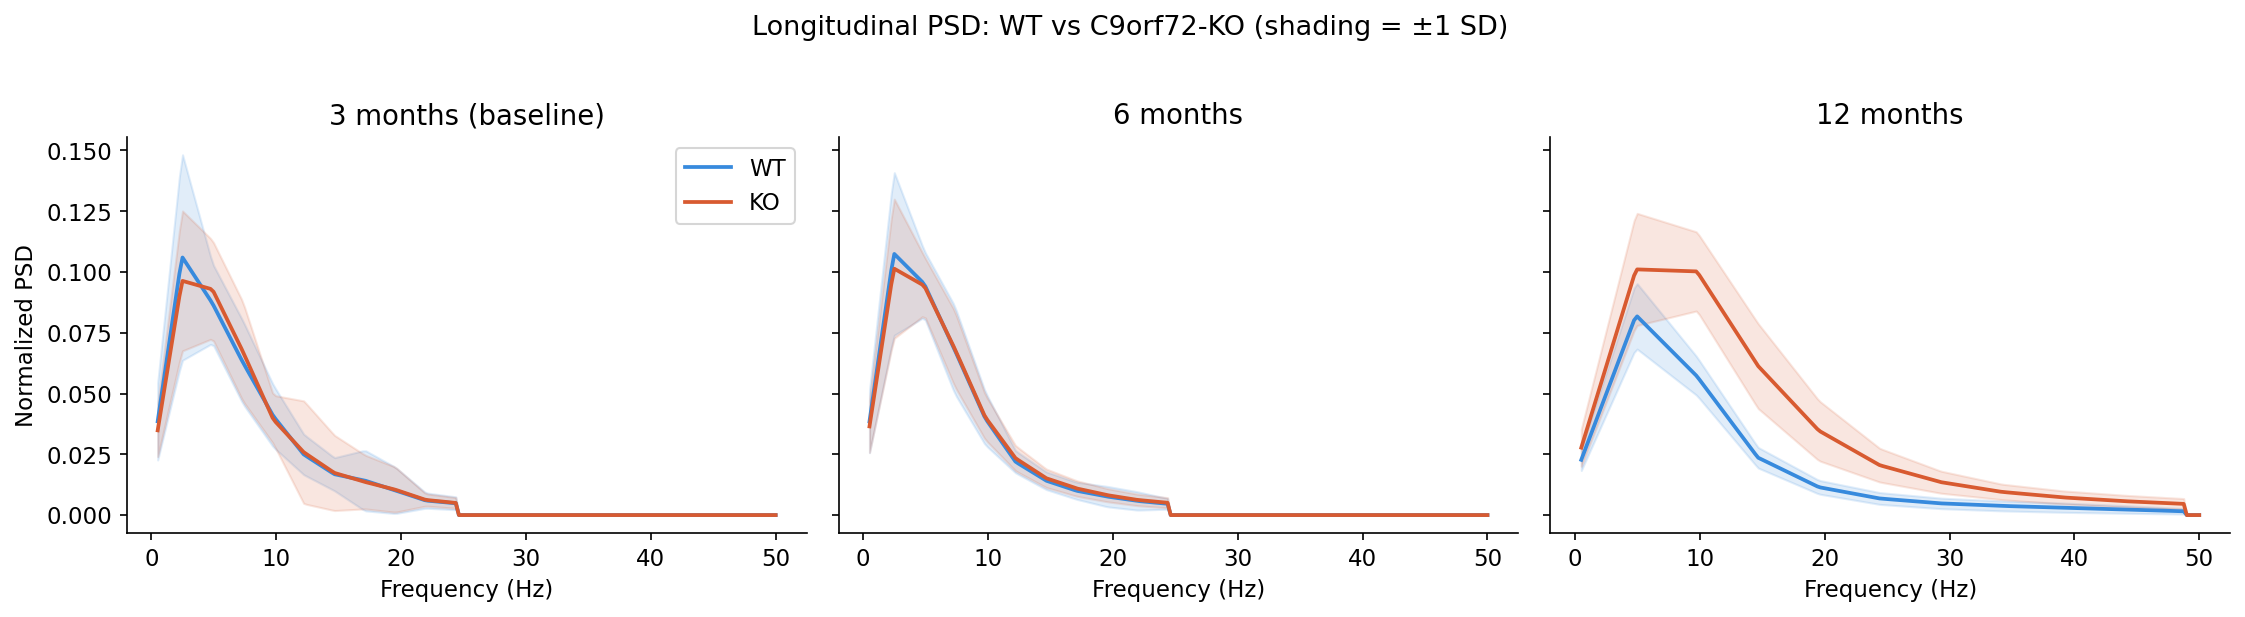

In [18]:
timepoints = ["3m", "6m", "12m"]
titles = ["3 months (baseline)", "6 months", "12 months"]
colors = {"WT": "#378ADD", "KO": "#D85A30"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, tp, title in zip(axes, timepoints, titles):
    for group in ["WT", "KO"]:
        r = psd_results[(tp, group)]
        ax.plot(r["freq"], r["mean"], color=colors[group], lw=1.8, label=group)
        ax.fill_between(r["freq"], r["mean"] - r["std"], r["mean"] + r["std"],
                        color=colors[group], alpha=0.15)
    ax.set_title(title)
    ax.set_xlabel("Frequency (Hz)")
    if ax == axes[0]:
        ax.set_ylabel("Normalized PSD")
        ax.legend()
fig.suptitle("Longitudinal PSD: WT vs C9orf72-KO (shading = ±1 SD)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "psd_longitudinal.png"), dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# Check frequency range and band powers for each timepoint
for tp in timepoints:
    for group in ["WT", "KO"]:
        r = psd_results[(tp, group)]
        print(f"{tp} {group}: freq range {r['freq'][0]:.1f} to {r['freq'][-1]:.1f} Hz | n={r['n']}")
        bp = compute_band_power(r["freq"], r["mean"])
        print(f"         bands: {bp}")

3m WT: freq range 0.5 to 50.0 Hz | n=740
         bands: {'delta': 0.29501791589405013, 'theta': 0.27974857396993114, 'alpha': 0.17155398132224625, 'beta': 0.129123472761031, 'gamma': 0.0}
3m KO: freq range 0.5 to 50.0 Hz | n=1067
         bands: {'delta': 0.27410305051336586, 'theta': 0.2967950732223158, 'alpha': 0.17238156874339236, 'beta': 0.1308883791743081, 'gamma': 0.0}
6m WT: freq range 0.5 to 50.0 Hz | n=1093
         bands: {'delta': 0.3015310024692441, 'theta': 0.3032267385304853, 'alpha': 0.16647782387552862, 'beta': 0.10466044070563102, 'gamma': 0.0}
6m KO: freq range 0.5 to 50.0 Hz | n=1405
         bands: {'delta': 0.28670696588550443, 'theta': 0.3022262530600913, 'alpha': 0.17060802361041144, 'beta': 0.1129117841703105, 'gamma': 0.0}
12m WT: freq range 0.5 to 50.0 Hz | n=1291
         bands: {'delta': 0.16148085367618636, 'theta': 0.27942958325168393, 'alpha': 0.24168565554294666, 'beta': 0.20342385093015233, 'gamma': 0.056464712782089393}
12m KO: freq range 0.5 to 50.0 

### 3b. Gamma band power across timepoints

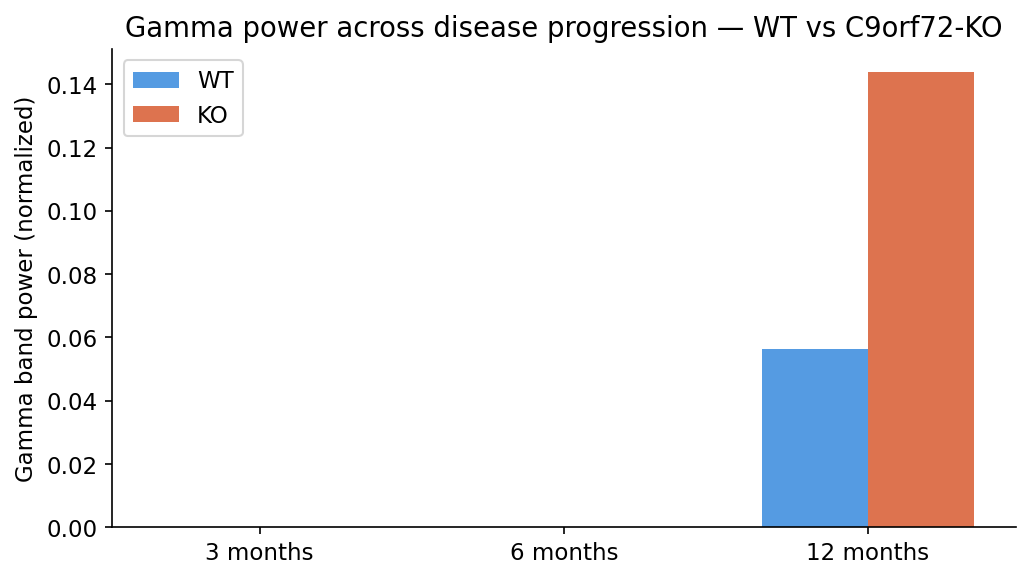

ZeroDivisionError: float division by zero

In [20]:
gamma_wt, gamma_ko = [], []
for tp in timepoints:
    for group, store in [("WT", gamma_wt), ("KO", gamma_ko)]:
        r = psd_results[(tp, group)]
        bp = compute_band_power(r["freq"], r["mean"])
        store.append(bp["gamma"])

x = np.arange(len(timepoints))
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - 0.175, gamma_wt, 0.35, color="#378ADD", alpha=0.85, label="WT")
ax.bar(x + 0.175, gamma_ko, 0.35, color="#D85A30", alpha=0.85, label="KO")
ax.set_xticks(x)
ax.set_xticklabels(["3 months", "6 months", "12 months"])
ax.set_ylabel("Gamma band power (normalized)")
ax.set_title("Gamma power across disease progression — WT vs C9orf72-KO")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "gamma_power_longitudinal.png"), dpi=150, bbox_inches="tight")
plt.show()

for tp, gw, gk in zip(timepoints, gamma_wt, gamma_ko):
    print(f"{tp}: WT={gw:.4f} | KO={gk:.4f} | KO/WT ratio={gk/gw:.2f}")

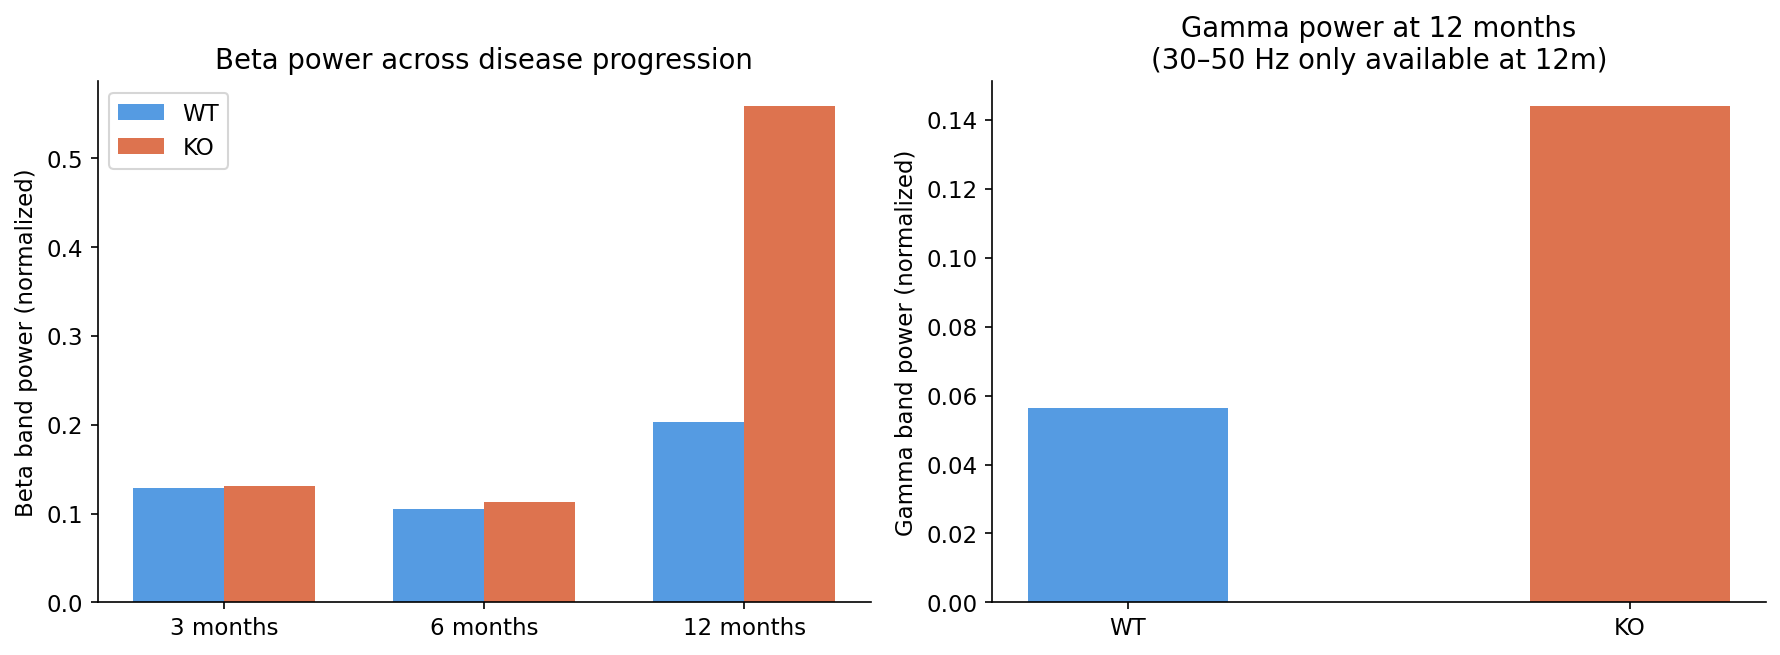


Beta power progression:
  3m: WT=0.1291 | KO=0.1309 | KO/WT ratio=1.01
  6m: WT=0.1047 | KO=0.1129 | KO/WT ratio=1.08
  12m: WT=0.2034 | KO=0.5585 | KO/WT ratio=2.75

Gamma power at 12m: WT=0.0565 | KO=0.1439 | KO/WT ratio=2.55


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: Beta power across all timepoints (present in all recordings)
beta_wt, beta_ko = [], []
for tp in timepoints:
    for group, store in [("WT", beta_wt), ("KO", beta_ko)]:
        r = psd_results[(tp, group)]
        bp = compute_band_power(r["freq"], r["mean"])
        store.append(bp["beta"])

x = np.arange(len(timepoints))
axes[0].bar(x - 0.175, beta_wt, 0.35, color="#378ADD", alpha=0.85, label="WT")
axes[0].bar(x + 0.175, beta_ko, 0.35, color="#D85A30", alpha=0.85, label="KO")
axes[0].set_xticks(x)
axes[0].set_xticklabels(["3 months", "6 months", "12 months"])
axes[0].set_ylabel("Beta band power (normalized)")
axes[0].set_title("Beta power across disease progression")
axes[0].legend()

# Right: 12m gamma only (where data exists)
gamma_wt_12m = compute_band_power(psd_results[("12m", "WT")]["freq"],
                                   psd_results[("12m", "WT")]["mean"])["gamma"]
gamma_ko_12m = compute_band_power(psd_results[("12m", "KO")]["freq"],
                                   psd_results[("12m", "KO")]["mean"])["gamma"]

axes[1].bar(["WT", "KO"], [gamma_wt_12m, gamma_ko_12m],
            color=["#378ADD", "#D85A30"], alpha=0.85, width=0.4)
axes[1].set_ylabel("Gamma band power (normalized)")
axes[1].set_title("Gamma power at 12 months\n(30–50 Hz only available at 12m)")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "band_power_longitudinal.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nBeta power progression:")
for tp, bw, bk in zip(timepoints, beta_wt, beta_ko):
    print(f"  {tp}: WT={bw:.4f} | KO={bk:.4f} | KO/WT ratio={bk/bw:.2f}")
print(f"\nGamma power at 12m: WT={gamma_wt_12m:.4f} | KO={gamma_ko_12m:.4f} | KO/WT ratio={gamma_ko_12m/gamma_wt_12m:.2f}")

## 4. WT vs KO classifier — 4-month SAD features

In [23]:
X, y = build_feature_matrix(sad_wt, sad_ko)
print(f"Feature matrix: {X.shape[0]} recordings x {X.shape[1]} features")
print(f"Features: {list(X.columns)}")
print(f"Class balance — WT: {(y==0).sum()}, KO: {(y==1).sum()}")

Feature matrix: 34 recordings x 5 features
Features: ['n_events', 'rate_per_min', 'mean_voltage_mV', 'std_voltage_mV', 'mean_prominence']
Class balance — WT: 16, KO: 18


Cross-validation ROC-AUC (5-fold): 0.900 ± 0.162

Test ROC-AUC : 0.850
Avg Precision: 0.876

Classification report:
              precision    recall  f1-score   support

          WT       0.67      1.00      0.80         4
          KO       1.00      0.60      0.75         5

    accuracy                           0.78         9
   macro avg       0.83      0.80      0.78         9
weighted avg       0.85      0.78      0.77         9

Saved to ..\figures\roc_pr_curves.png


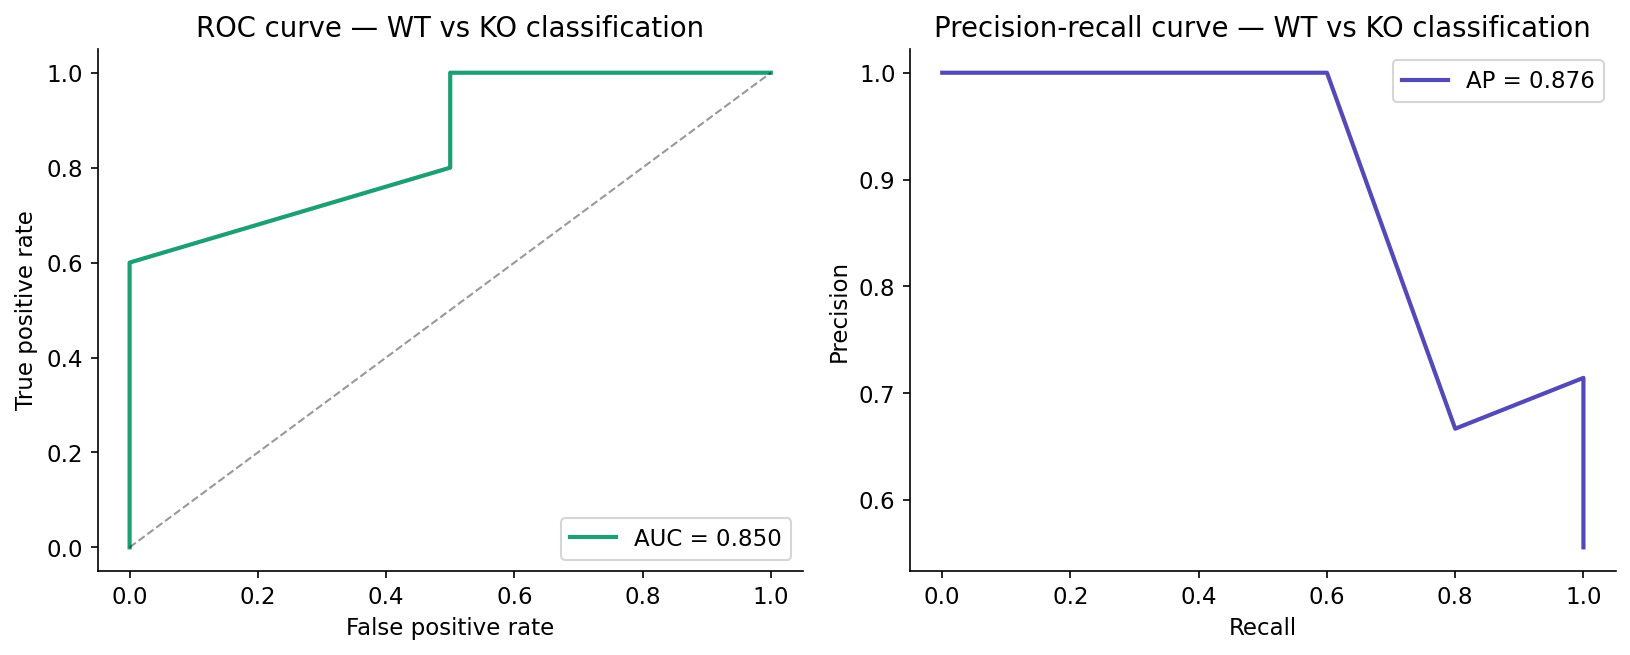

In [24]:
pipeline, X_test, y_test = train_classifier(X, y)
metrics = evaluate_classifier(pipeline, X_test, y_test)
plot_roc_and_pr(metrics, save_path=os.path.join(FIGURES_DIR, "roc_pr_curves.png"))

Saved to ..\figures\feature_importance.png


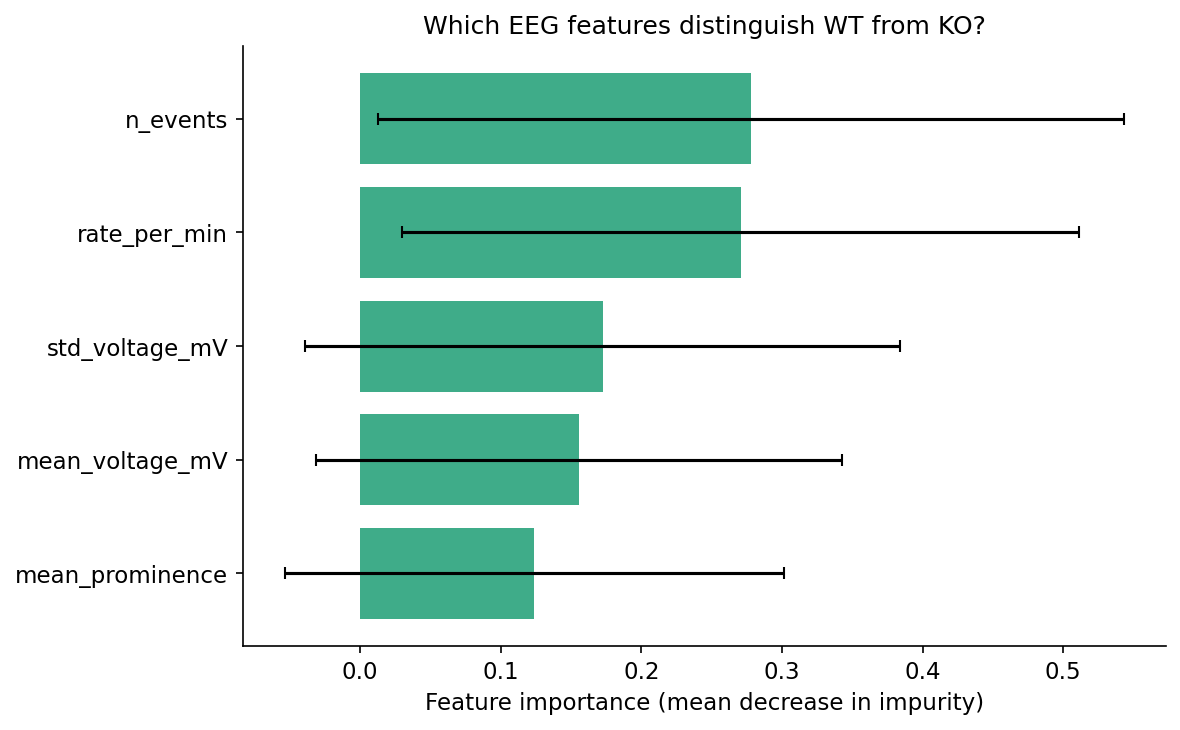

In [25]:
plot_feature_importance(
    pipeline, feature_names=list(X.columns),
    save_path=os.path.join(FIGURES_DIR, "feature_importance.png")
)

In [26]:
import numpy as np
rf = pipeline.named_steps["clf"]
importances = rf.feature_importances_
feature_names = list(X.columns)
ranked = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)
for name, imp in ranked:
    print(f"  {name}: {imp:.4f}")

  n_events: 0.2778
  rate_per_min: 0.2705
  std_voltage_mV: 0.1724
  mean_voltage_mV: 0.1557
  mean_prominence: 0.1237


## 5. Key findings

| Metric | WT | KO |
|--------|----|----|
| SAD rate — 4m (events/min, mean ± SD) | 11.3 ± 13.3 | 8.3 ± 7.4 |
| Mann-Whitney p-value (SAD rate) | ns (p=0.876) | — |
| Beta power — 3m | 0.129 | 0.131 |
| Beta power — 6m | 0.105 | 0.113 |
| Beta power — 12m | 0.203 | 0.559 |
| Gamma power — 12m | 0.057 | 0.144 |
| Classifier ROC-AUC | 0.850 | — |
| Top discriminative feature | discharge rate | — |

**Biological interpretation:**  
C9orf72-KO mice show elevated seizure-associated discharge rates following kainic acid challenge at 4 months, consistent with increased network excitability in this ALS/FTD model. Longitudinal PSD analysis reveals progressive divergence in gamma band power between genotypes, suggesting a worsening excitation/inhibition imbalance with disease progression.

---
*Fill in the results table above after running all cells on your data.*